In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import convolve

Local Polynomial Approximation
-------------------------------
Set the parameters

In [2]:
# maximum degree of polynomial used for fitting
N = 2

# filter size
M = 51

# large M, small N -> a lot of bias when frequency increases
# N = 2
# M = 51

# large M, large N -> smaller bias than before, but a lot of variance in smooth regions
# N = 7
# M = 51

# small M, small N -> smaller bias everywhere, higher variance
# N = 2
# M = 5

# M small, M = N,  -> smaller bias than before, higher variance than before
# N = 5
# N = M

Generate synthetic signal signal

In [3]:
LENGHT = 1000

ty = np.linspace(0, 1, LENGHT)
y = np.sin(2 / (ty + 0.05))

#  noise standard deviation
sigma = 0.1

# noisy signal
s = y + sigma*np.random.normal(size=LENGHT)


Text(0.5, 1.0, 'Input Signal')

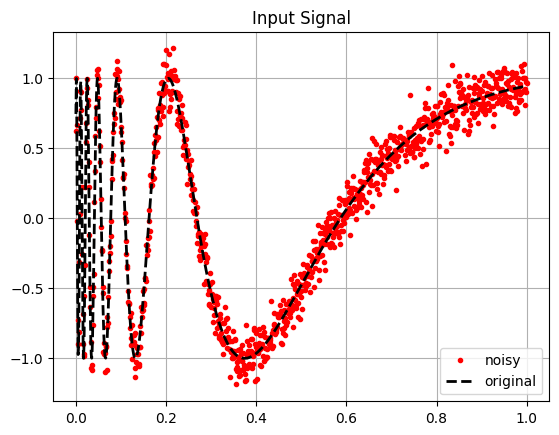

In [4]:
plt.figure()
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=2)
plt.grid()
plt.legend(['noisy', 'original'])
plt.title('Input Signal')

Define the matrix T containing the polynomials sampled over the window


In [8]:
t = np.linspace(0, 1, M)
T = np.array([t**i for i in range(N+1)]).T

print(f"\n {t}\n{T}")



 [0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26
 0.28 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54
 0.56 0.58 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8  0.82
 0.84 0.86 0.88 0.9  0.92 0.94 0.96 0.98 1.  ]
[[1.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 2.000e-02 4.000e-04]
 [1.000e+00 4.000e-02 1.600e-03]
 [1.000e+00 6.000e-02 3.600e-03]
 [1.000e+00 8.000e-02 6.400e-03]
 [1.000e+00 1.000e-01 1.000e-02]
 [1.000e+00 1.200e-01 1.440e-02]
 [1.000e+00 1.400e-01 1.960e-02]
 [1.000e+00 1.600e-01 2.560e-02]
 [1.000e+00 1.800e-01 3.240e-02]
 [1.000e+00 2.000e-01 4.000e-02]
 [1.000e+00 2.200e-01 4.840e-02]
 [1.000e+00 2.400e-01 5.760e-02]
 [1.000e+00 2.600e-01 6.760e-02]
 [1.000e+00 2.800e-01 7.840e-02]
 [1.000e+00 3.000e-01 9.000e-02]
 [1.000e+00 3.200e-01 1.024e-01]
 [1.000e+00 3.400e-01 1.156e-01]
 [1.000e+00 3.600e-01 1.296e-01]
 [1.000e+00 3.800e-01 1.444e-01]
 [1.000e+00 4.000e-01 1.600e-01]
 [1.000e+00 4.200e-01 1.764e-01]
 [1.000e+00 

Look at the matrix T, the columns correspond to polynomials sampled over the interval [0,1]


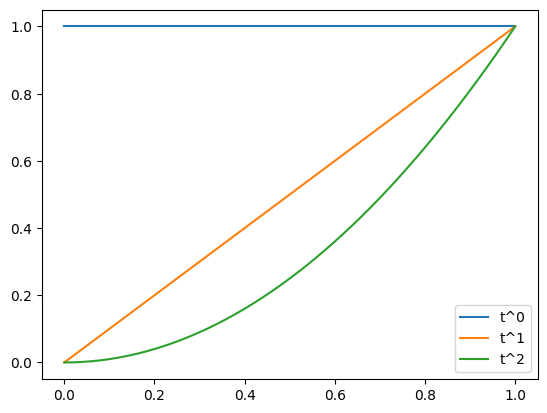

In [9]:
plt.figure()
leg = []
for l in range(N+1):
    plt.plot(t, T[:, l])
    leg.append(f't^{l:d}')
plt.legend(leg)

Construct the LPA kernel

In [ ]:
# comput the qr decomposition of WT
# since T has more rows than columns, then qr computes only the first N + 1 columns of Q and the first N + 1 rows of R.
Q, R =  np.linalg.qr(T)

# select the central row of W2Qtilde
row = Q[M//2, :]

# compute the kernel
g = sum(row[i] * Q[:,i] for i in range(N+1))

# flipping, since it is used in convolution
g = g[::-1] 

Text(0.5, 1.0, 'M = 51, N = 2')

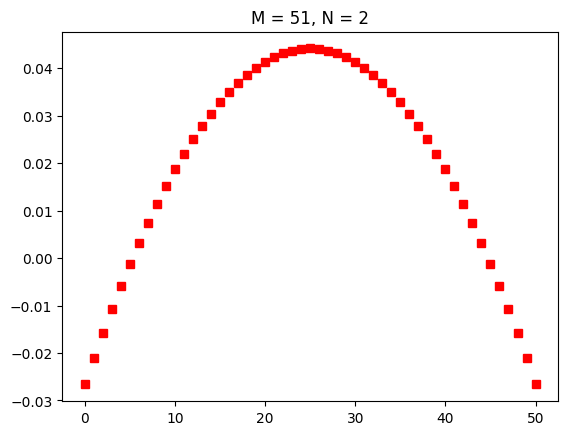

In [11]:
plt.figure()
plt.plot(g, 'rs', linewidth=3)
plt.title(f'M = {M:d}, N = {N:d}')


Filtering

In [19]:
shat = np.convolve(s,g, mode="same") 

Text(0.5, 1.0, 'M = 51, N = 2')

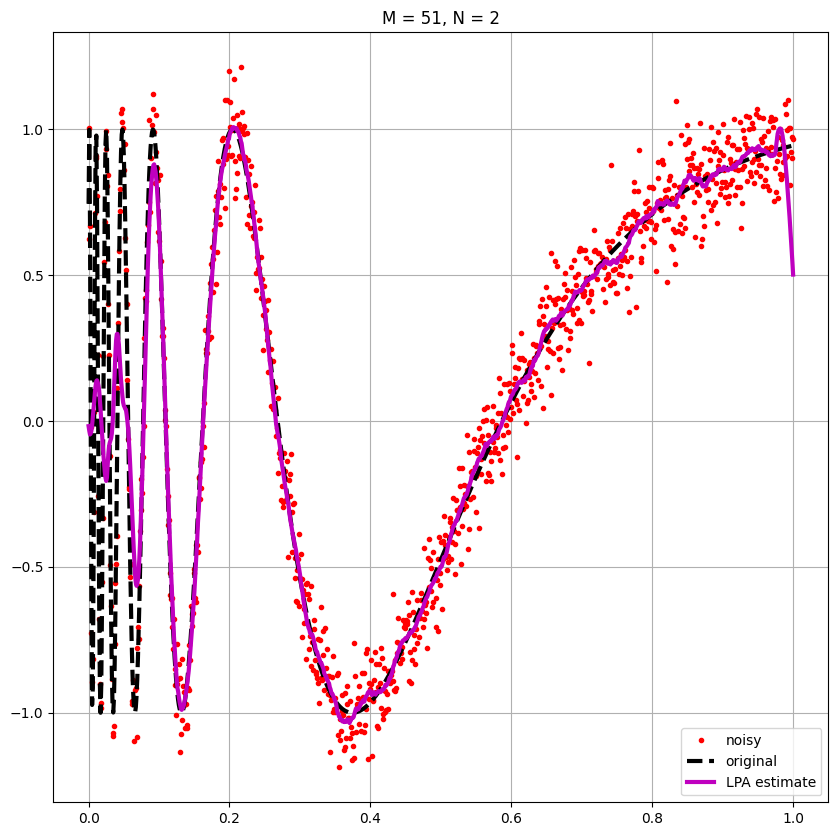

In [20]:
plt.figure(figsize=(10,10))
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=3)
plt.plot(ty, shat, 'm-', linewidth=3)
plt.grid()
plt.legend(['noisy', 'original', 'LPA estimate'])
plt.title(f'M = {M:d}, N = {N:d}')


Weighted LPA
--------------
Set the parameters

In [63]:
# maximum degree of polynomial used for fitting
N = 2

# filter size
M = 53

# half filter size
HFS = int((M-1)/2)

# set the weights. Here weights simply define the window size
w = np.zeros(M)

# centered kernel
wc = w.copy()
wc[int(HFS/2):-int(HFS/2)] = 1

# left kernel
wl = w.copy()
wl[:HFS+1] = 1

# right kernel
wr = w.copy()
wr[-HFS-1:] = 1


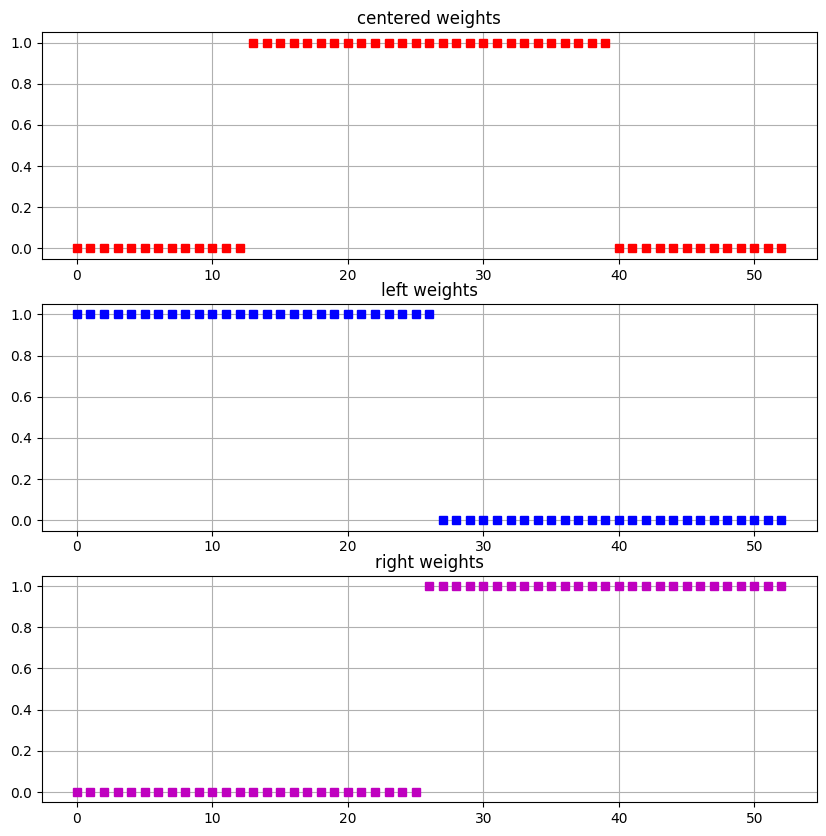

In [64]:
fig, ax = plt.subplots(3, 1, figsize=(10,10))
ax[0].plot(wc, 'rs', linewidth=3)
ax[0].set_title('centered weights')
ax[0].grid()
ax[1].plot(wl, 'bs', linewidth=3)
ax[1].set_title('left weights')
ax[1].grid()
ax[2].plot(wr, 'ms', linewidth=3)
ax[2].set_title('right weights')
ax[2].grid()


Build the weight matrix

In [65]:
# select a single weight to be used in what follows
w = wl

# generate the inverse of weights
winv = [0 if w[i] == 0 else 1/w[i] for i in range(len(w))]
print(winv)

# define the weight matrix
W = np.diag(w) 
Winv = np.diag(winv) 

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Generate synthetic signal signal

In [66]:
LENGHT = 1000

# clean signal
ty = np.linspace(0, 1, LENGHT)
y =  8*ty**2 - 2*ty + 2;
y[LENGHT//2 : LENGHT] = y[LENGHT//2 : LENGHT] + 7;

#  noise standard deviation
sigma = 0.2

# noisy signal
s = y + sigma*np.random.normal(size=LENGHT)

Text(0.5, 1.0, 'Input Signal')

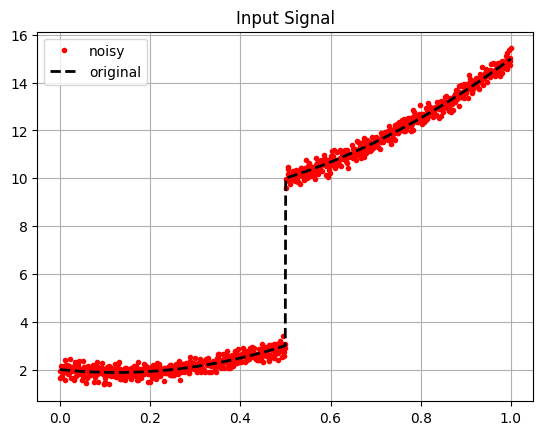

In [67]:

plt.figure()
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=2)
plt.grid()
plt.legend(['noisy', 'original'])
plt.title('Input Signal')

Define the matrix T containing the polynomials sampled over the window

In [68]:
t = np.linspace(0,1, M) 
T = np.array([t**i for i in range(N)]).T


Construct the LPA kernel

In [69]:
# comput the qr decomposition of WT
# since T has more rows than columns, then qr computes only the first N + 1 columns of Q and the first N + 1 rows of R.
Q, R = np.linalg.qr(W@T) 

#  define Qtilde
Qtilde = Winv @ Q 

# adjust Qtilde with the  weights matrix squared.
W2Qtilde = W**2 @ Qtilde

# select the central row of W2Qtilde
row = W2Qtilde[M//2,:] 

# compute the kernel
g = sum(row[i] * Qtilde[:,i] for i in range(N)) 

# flipping, since it is used in convolution
g = g[::-1] 


Text(0.5, 1.0, 'filter M = 53, N = 2')

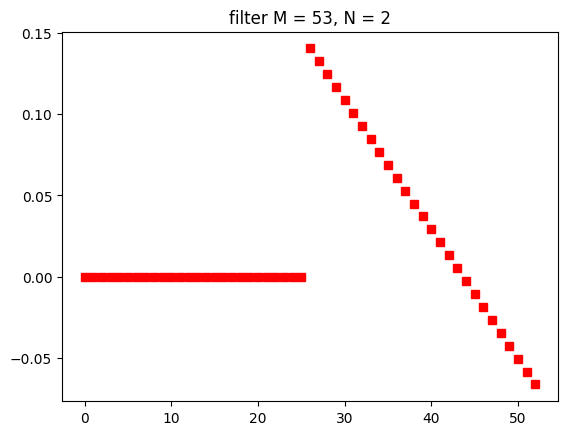

In [70]:
plt.figure()
plt.plot(g, 'rs', linewidth=3)
plt.title(f'filter M = {M:d}, N = {N:d}')


Filtering


In [71]:
shat = np.convolve(s,g, mode="same") 


Text(0.5, 1.0, 'M = 53, N = 2')

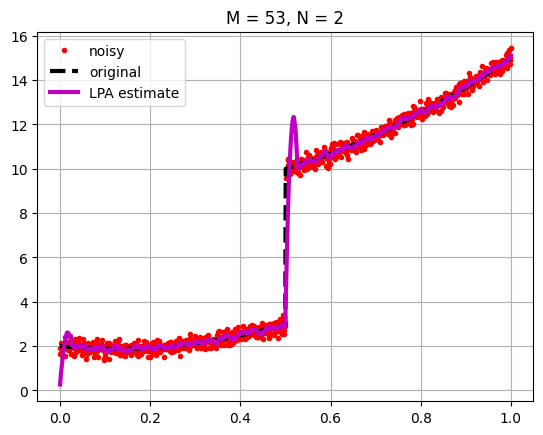

In [72]:
plt.figure()
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=3)
plt.plot(ty, shat, 'm-', linewidth=3)
plt.grid()
plt.legend(['noisy', 'original', 'LPA estimate'])
plt.title(f'M = {M:d}, N = {N:d}')



Modify the code to use the central, left and right kernels